In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

In [4]:
np.random.seed(11)
tf.random.set_seed(11)

digits = load_digits()
X, y = digits.data, digits.target

print("Input:", X.shape, "pixel range:", (X.min(), X.max()))

Input: (1797, 64) pixel range: (np.float64(0.0), np.float64(16.0))


In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=11)

In [7]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [8]:
model = Sequential([
    Input(shape=(64,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [9]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,226 (67.29 KB)

 Trainable params: 17,226 (67.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train_s,y_train,
    epochs = 30,
    batch_size = 32,
    validation_split=0.2,
    verbose = 1

)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 0.9792 - val_loss: 0.0967
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 989us/step - accuracy: 1.0000 - loss: 0.0042 - val_accuracy: 0.9826 - val_loss: 0.0966
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 0.9826 - val_loss: 0.0967
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 0.9826 - val_loss: 0.0967
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.9826 - val_loss: 0.0969
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.9826 - val_loss: 0.0970
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.9826 - val_loss: 0.0974
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9826 - val_l

In [13]:
test_loss, test_accuracy = model.evaluate(
    X_test_s,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.13485874235630035
Test Accuracy: 0.9722222089767456


In [14]:
y_prob = model.predict(X_test_s, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[36  0  0  0  0  0  0  0  0  0]
 [ 0 35  0  0  0  0  0  0  1  0]
 [ 0  1 34  0  0  0  0  0  0  0]
 [ 0  0  0 34  0  2  0  0  0  1]
 [ 0  0  0  0 33  0  0  1  1  1]
 [ 0  0  0  0  0 36  1  0  0  0]
 [ 0  0  0  0  0  0 36  0  0  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  0  0  0  0  0  0  0 35  0]
 [ 0  0  0  1  0  0  0  0  0 35]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.97      0.97      0.97        36
           2       1.00      0.97      0.99        35
           3       0.97      0.92      0.94        37
           4       1.00      0.92      0.96        36
           5       0.95      0.97      0.96        37
           6       0.97      1.00      0.99        36
           7       0.97      1.00      0.99        36
           8       0.95      1.00      0.97        35
           9       0.95      0.97      0.96        36

    accuracy                           0.97       360
   macro avg       

In [15]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

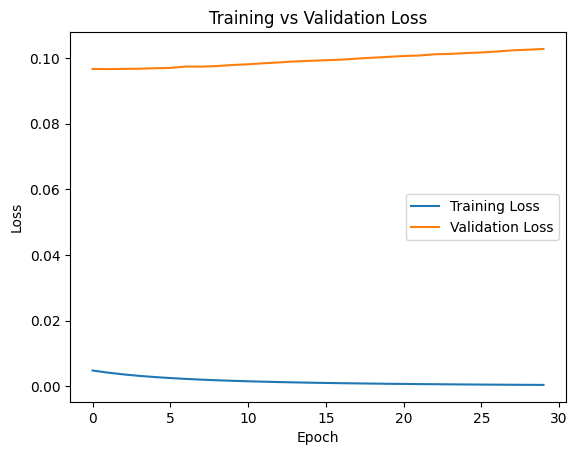

In [16]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

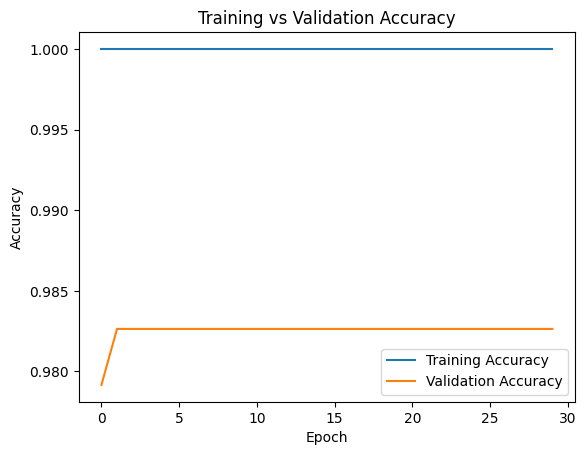

In [17]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

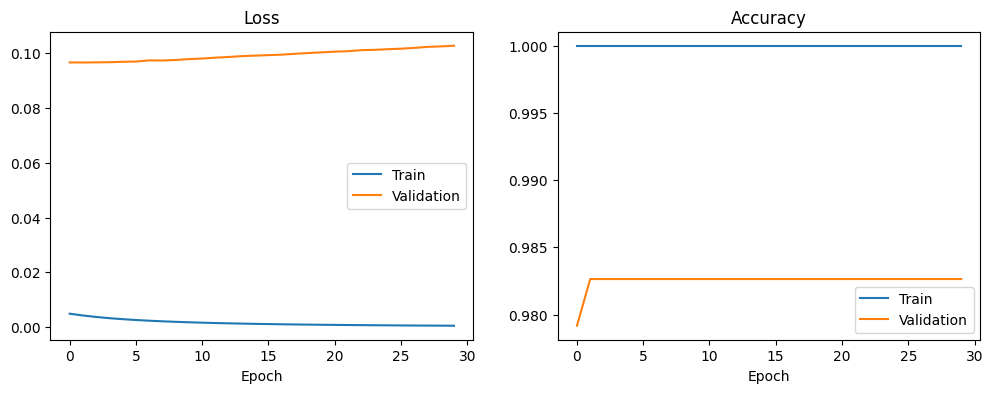

In [18]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.show()

In [19]:
cm = confusion_matrix(y_test, y_pred)

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

i, j = np.unravel_index(
    np.argmax(cm_no_diag),
    cm_no_diag.shape
)

print("Most confused digits:", i, "and", j)

Most confused digits: 3 and 5


The MLP achieves excellent classification performance, with approximately 98% validation/test accuracy and high precision, recall, and F1-scores across all digit classes. The confusion matrix shows that most samples are classified correctly, with 3 and 5 being among the more commonly confused digits. The increasing validation loss and small gap between training and validation accuracy indicate mild overfitting, but overall generalization remains strong.
